ARTI406 - Machine Learning

# Assignment 1: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

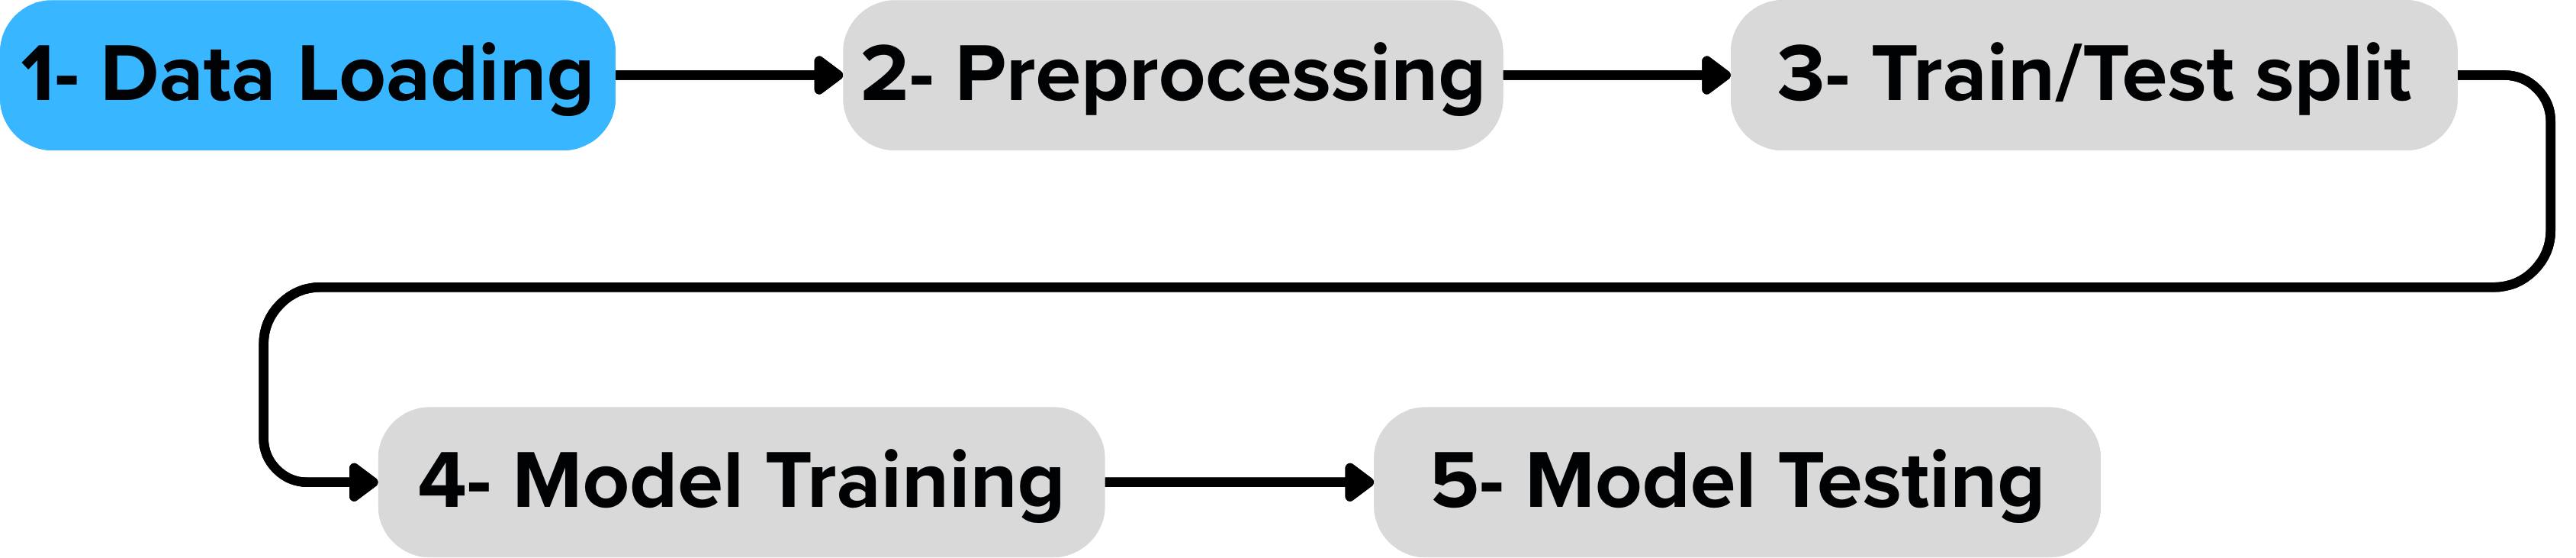

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [37]:
# Load Dataset
df = pd.read_csv("depression_data.csv")
# Display first 5 rows. If you want to display all rows, use df.head(-1)
df.head(-1)

,Name,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
0,Christine Barker,31,Married,Bachelor's Degree,2,Non-smoker,Active,Unemployed,26265.67,Moderate,Moderate,Fair,Yes,No,Yes,Yes
1,Jacqueline Lewis,55,Married,High School,1,Non-smoker,Sedentary,Employed,42710.36,High,Unhealthy,Fair,Yes,No,No,Yes
2,Shannon Church,78,Widowed,Master's Degree,1,Non-smoker,Sedentary,Employed,125332.79,Low,Unhealthy,Good,No,No,Yes,No
3,Charles Jordan,58,Divorced,Master's Degree,3,Non-smoker,Moderate,Unemployed,9992.78,Moderate,Moderate,Poor,No,No,No,No
4,Michael Rich,18,Single,High School,0,Non-smoker,Sedentary,Unemployed,8595.08,Low,Moderate,Fair,Yes,No,Yes,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413762,Janice Robertson,28,Single,Bachelor's Degree,0,Non-smoker,Active,Unemployed,5971.27,Moderate,Moderate,Fair,Yes,Yes,No,No
413763,Sean Miller,68,Married,Master's Degree,0,Former,Moderate,Employed,109233.43,Low,Healthy,Good,No,No,No,No
413764,Christina Brown,26,Single,Bachelor's Degree,0,Current,Active,Employed,96760.97,Low,Healthy,Poor,Yes,Yes,No,Yes
413765,Matthew Jenkins,57,Married,Bachelor's Degree,0,Non-smoker,Sedentary,Employed,77353.26,Moderate,Moderate,Fair,No,No,Yes,Yes


### Check Missing Values

In [38]:
# Check all values
print(df.isna())

         Name    Age  Marital Status  Education Level  Number of Children  \
0       False  False           False            False               False   
1       False  False           False            False               False   
2       False  False           False            False               False   
3       False  False           False            False               False   
4       False  False           False            False               False   
...       ...    ...             ...              ...                 ...   
413763  False  False           False            False               False   
413764  False  False           False            False               False   
413765  False  False           False            False               False   
413766  False  False           False            False               False   
413767  False  False           False            False               False   

        Smoking Status  Physical Activity Level  Employment Status  Income 

In [39]:
print(df.isna().sum())

Name                            0
Age                             0
Marital Status                  0
Education Level                 0
Number of Children              0
Smoking Status                  0
Physical Activity Level         0
Employment Status               0
Income                          0
Alcohol Consumption             0
Dietary Habits                  0
Sleep Patterns                  0
History of Mental Illness       0
History of Substance Abuse      0
Family History of Depression    0
Chronic Medical Conditions      0
dtype: int64


### Check duplicate rows

In [40]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

Series([], dtype: bool)

### No. of rows and columns

In [41]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (413768, 16) 

number of rows:  413768
number of columns:  16


### Data type of columns

In [42]:
# viewing the data types of columns
df.dtypes

Name                             object
Age                               int64
Marital Status                   object
Education Level                  object
Number of Children                int64
Smoking Status                   object
Physical Activity Level          object
Employment Status                object
Income                          float64
Alcohol Consumption              object
Dietary Habits                   object
Sleep Patterns                   object
History of Mental Illness        object
History of Substance Abuse       object
Family History of Depression     object
Chronic Medical Conditions       object
dtype: object

In [44]:
print(df.columns)

Index(['Name', 'Age', 'Marital Status', 'Education Level',
       'Number of Children', 'Smoking Status', 'Physical Activity Level',
       'Employment Status', 'Income', 'Alcohol Consumption', 'Dietary Habits',
       'Sleep Patterns', 'History of Mental Illness',
       'History of Substance Abuse', 'Family History of Depression',
       'Chronic Medical Conditions'],
      dtype='object')


In [45]:
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Income'] = pd.to_numeric(df['Income'], errors='coerce')
df['Number of Children'] = pd.to_numeric(df['Number of Children'], errors='coerce')

df.dtypes

Name                             object
Age                               int64
Marital Status                   object
Education Level                  object
Number of Children                int64
Smoking Status                   object
Physical Activity Level          object
Employment Status                object
Income                          float64
Alcohol Consumption              object
Dietary Habits                   object
Sleep Patterns                   object
History of Mental Illness        object
History of Substance Abuse       object
Family History of Depression     object
Chronic Medical Conditions       object
dtype: object

In [46]:
# Statistical summary
df.describe(include='all')

,Name,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
count,413768,413768.000000,413768,413768,413768.000000,413768,413768,413768,413768.000000,413768,413768,413768,413768,413768,413768,413768
unique,196851,NaN,4,5,NaN,3,3,2,NaN,3,3,3,2,2,2,2
top,Michael Smith,NaN,Married,Bachelor's Degree,NaN,Non-smoker,Sedentary,Employed,NaN,Moderate,Unhealthy,Fair,No,No,No,No
freq,198,NaN,240444,124329,NaN,247416,176850,265659,NaN,173440,170817,196789,287943,284880,302515,277561
mean,NaN,49.000713,NaN,NaN,1.298972,NaN,NaN,NaN,50661.707971,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,18.158759,NaN,NaN,1.237054,NaN,NaN,NaN,40624.100565,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,18.000000,NaN,NaN,0.000000,NaN,NaN,NaN,0.410000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,33.000000,NaN,NaN,0.000000,NaN,NaN,NaN,21001.030000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,49.000000,NaN,NaN,1.000000,NaN,NaN,NaN,37520.135000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,65.000000,NaN,NaN,2.000000,NaN,NaN,NaN,76616.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Descriptive summary Statistics

### Univariate Analysis

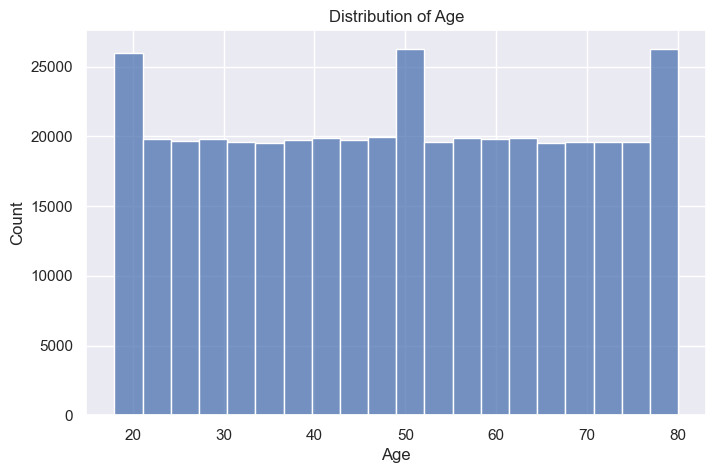

In [48]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20)
plt.title("Distribution of Age")
plt.show()


- Shows how shipment sizes are distributed
- Right skew = many small shipments, few large ones

### Distribution of Income

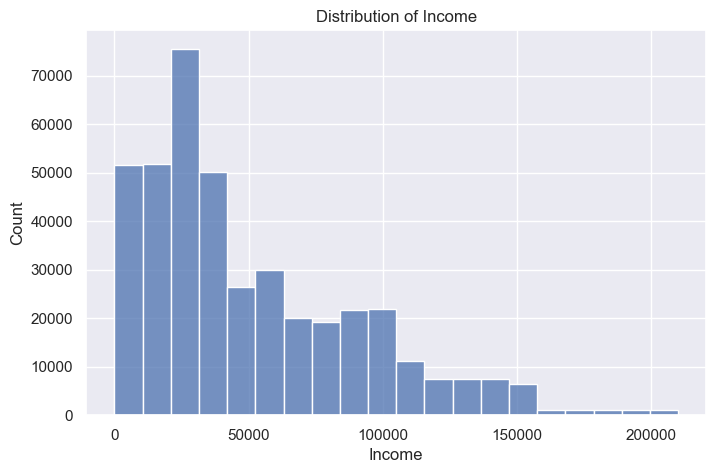

In [50]:
plt.figure(figsize=(8,5))
sns.histplot(df['Income'], bins=20)
plt.title("Distribution of Income")
plt.show()

## Bivariate Analysis

### Income and Education level

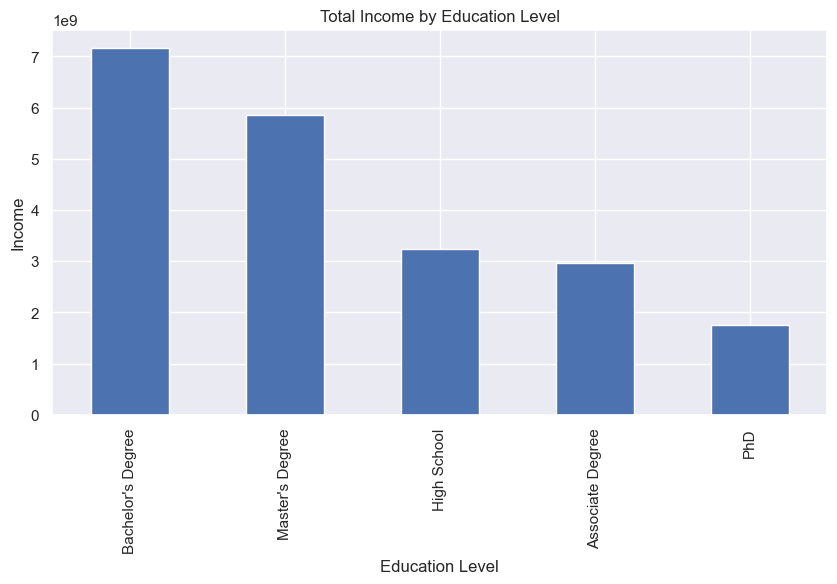

Education Level
Bachelor's Degree    7.162602e+09
Master's Degree      5.845821e+09
High School          3.235822e+09
Associate Degree     2.966097e+09
PhD                  1.751852e+09
Name: Income, dtype: float64

In [57]:
education_income = df.groupby('Education Level')['Income'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
education_income.plot(kind='bar')
plt.title("Total Income by Education Level")
plt.ylabel("Income")
plt.show()

education_income


### Income by employment status

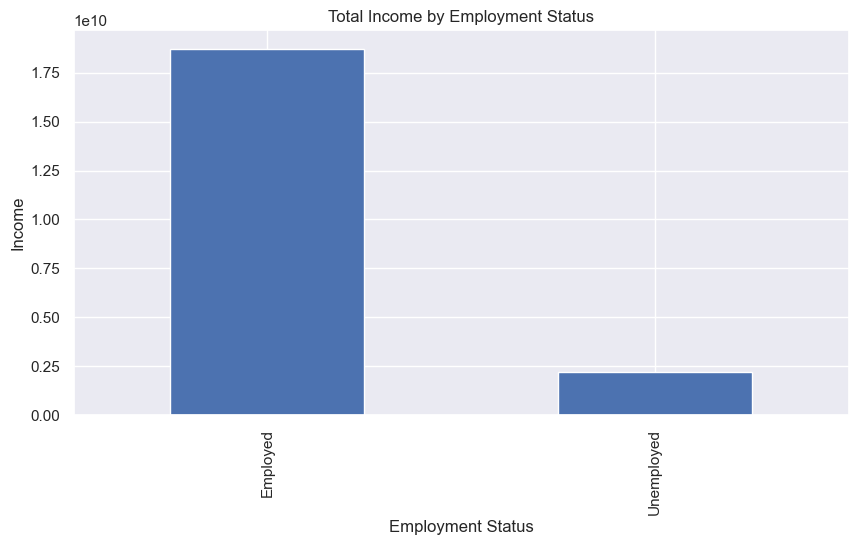

Employment Status
Employed      1.873588e+10
Unemployed    2.226314e+09
Name: Income, dtype: float64

In [60]:
income_by_employment = df.groupby('Employment Status')['Income'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
income_by_employment.plot(kind='bar')
plt.title("Total Income by Employment Status")
plt.ylabel("Income")
plt.xlabel("Employment Status")
plt.show()

income_by_employment



### Income by employment status

In [62]:
status_income = df.groupby('Employment Status')['Income'].sum().sort_values(ascending=False)

status_income.head(10)

Employment Status
Employed      1.873588e+10
Unemployed    2.226314e+09
Name: Income, dtype: float64

### Age vs Income Relationship

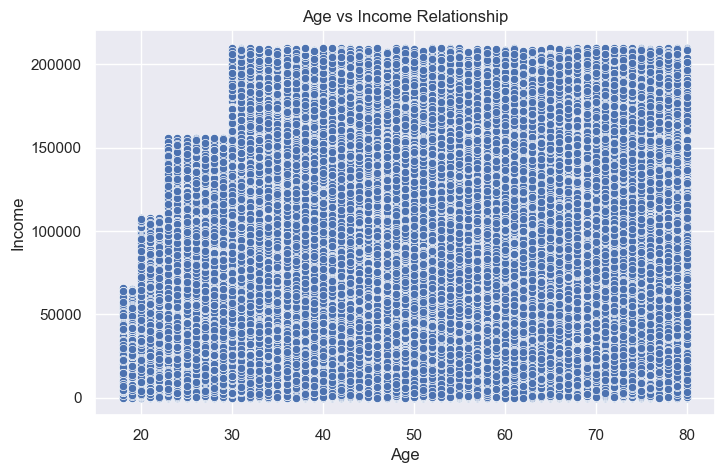

In [63]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Age', y='Income', data=df)
plt.title("Age vs Income Relationship")
plt.show()

### Correlation Matrix

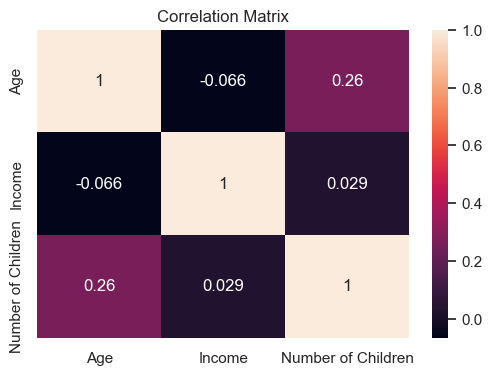

In [64]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Age', 'Income', 'Number of Children']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

- Correlation close to 1 = strong positive relationship
- Close to 0 = weak relationship

## Time-Based Analysis
### Income trend by Age groups

C:\Users\Admin\AppData\Local\Temp\ipykernel_39416\4204314516.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_income_trend = df.groupby('Age Group')['Income'].sum()


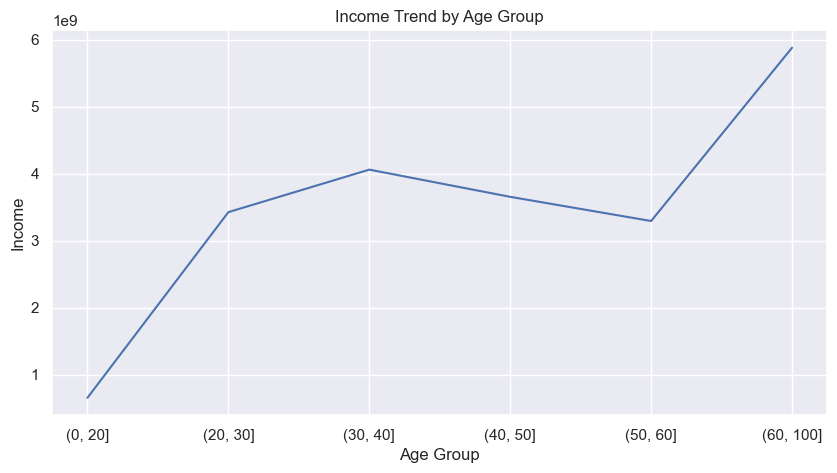

In [67]:
df['Age Group'] = pd.cut(df['Age'], bins=[0,20,30,40,50,60,100])

age_income_trend = df.groupby('Age Group')['Income'].sum()

plt.figure(figsize=(10,5))
age_income_trend.plot()
plt.title("Income Trend by Age Group")
plt.ylabel("Income")
plt.show()

# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the following to the assignment 1 folder.
1. Dataset file 
2. Dataset Description readme file
2. Jupyter Notebook
